In [ ]:
import numpy as np
import os
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().parents[0] if (Path.cwd().name == 'notebooks') else Path.cwd()
SRC = REPO_ROOT / 'src/sensiwrf'
sys.path.append(str(SRC))

import config
conf = config.conf

ModuleNotFoundError: No module named 'config'

In [6]:
REPO_ROOT

PosixPath('/nfsmounts/storage/scratch/jorge.gacitua/Sensitivity_Experiments')

In [ ]:
def modify_input_sounding(my_file, out_file, conf):
    # Read input sounding.
    input_sounding = read_input_sounding(my_file)

    ########################################################################
    # Modify the input sounding wind profile.
    ########################################################################
    if conf['modify_wind_profile'] :
      input_sounding['u'][:] = 0.0 #Overwrite the original wind profile
      input_sounding['v'][:] = 0.0

      if conf['shear_type'] == 'Linear' :
         #Linear shear component - U wind
         max_u = conf['shear_depth_u'] * conf['shear_strength_u']
         input_sounding['u'] = input_sounding['height'] * conf['shear_strength_u']
         input_sounding['u'][ input_sounding['height'] > conf['shear_depth_u'] ] = max_u
         #Linear shear component - V wind
         max_u = conf['shear_depth_v'] * conf['shear_strength_v']
         input_sounding['v'] = input_sounding['height'] * conf['shear_strength_v']
         input_sounding['v'][ input_sounding['height'] > conf['shear_depth_v'] ] = max_v

      if conf['shear_type'] == 'Curved' :
         #Maximum turning in wind direction (is a function of how much shear is explained by the curved part of the hodograph)
         #The maximum turning is pi (half a circle), if half the shear is associated with the curved part then a quarter circle hodograph is obtained.
         curved_shear_theta = conf['curved_shear_per'] * np.pi
         #Curved hodograp up to certain level, then linear shear.

         #Curved hodograp part
         if conf['curved_shear_per'] > 0.0 :
            curved_int_shear =  conf['int_total_shear'] * conf['curved_shear_per']
            curved_dep_shear =  conf['total_shear_depth'] * conf['curved_shear_per']
            curved_amp_shear =  curved_int_shear / curved_shear_theta
 
            mask = input_sounding['height'] <=  curved_dep_shear
            input_sounding['v'][mask] = -1.0 * curved_amp_shear * np.sin( (input_sounding['height'][mask] / curved_dep_shear )* curved_shear_theta )
            input_sounding['u'][mask] = -1.0 * curved_amp_shear * np.cos( (input_sounding['height'][mask] / curved_dep_shear )* curved_shear_theta )
         else :
            curved_amp_shear = 0.0

         #Linear shear part 
         u_ini = -1.0 * curved_amp_shear * np.cos( curved_shear_theta )  #U and V wind components at the base of the linear shear layer.
         v_ini = -1.0 * curved_amp_shear * np.sin( curved_shear_theta )

         linear_int_shear = conf['int_total_shear'] * (1.0 - conf['curved_shear_per'])

         u_fin = u_ini + linear_int_shear * np.sin( curved_shear_theta )
         v_fin = v_ini - linear_int_shear * np.cos( curved_shear_theta )

         mask = ( input_sounding['height'] >  curved_dep_shear ) & ( input_sounding['height'] <= conf['total_shear_depth'] )
         input_sounding['v'][mask] = v_ini + ( v_fin - v_ini) * ( input_sounding['height'][mask] - curved_dep_shear ) / ( conf['total_shear_depth'] - curved_dep_shear ) 
         input_sounding['u'][mask] = u_ini + ( u_fin - u_ini) * ( input_sounding['height'][mask] - curved_dep_shear ) / ( conf['total_shear_depth'] - curved_dep_shear )

         #Constant wind part.
         mask = input_sounding['height'] >=  conf['total_shear_depth']
         input_sounding['v'][mask] = v_fin
         input_sounding['u'][mask] = u_fin
		 
         linear_amp_shear = curved_int_shear / curved_shear_theta

      #print( input_sounding['u'] , input_sounding['v'] ) 


      #Low level jet component 
      input_sounding['u'] = input_sounding['u'] - conf['llj_amp'] * np.exp( -0.5 * ( conf['llj_h'] - input_sounding['height'] )**2 / conf['llj_width']**2  ) * np.sin( np.deg2rad(conf['llj_dir']) )
      input_sounding['v'] = input_sounding['v'] - conf['llj_amp'] * np.exp( -0.5 * ( conf['llj_h'] - input_sounding['height'] )**2 / conf['llj_width']**2  ) * np.cos( np.deg2rad(conf['llj_dir']) )

      #Add the surface wind speed to the entire profile.
      input_sounding['u'] = input_sounding['u'] + conf['surf_u']
      input_sounding['v'] = input_sounding['v'] + conf['surf_v']

      if conf['remove_mean_wind']:
          # Remove 0-6 km mean wind (this will keep the convection near the center of the
          # domain for a longer time)
          mask = input_sounding['height'] < 6000.0
          mean_u = np.mean(input_sounding['u'][mask])
          mean_v = np.mean(input_sounding['v'][mask])
          input_sounding['u'] = input_sounding['u'] - mean_u
          input_sounding['v'] = input_sounding['v'] - mean_v


    ########################################################################
    # Modify the input sounding theta profile.
    ########################################################################
    if conf['modify_theta_profile']:
        input_sounding['theta'][:] = 0.0
        input_sounding['surf_theta'] = conf['surf_theta']
        input_sounding['theta'][0] = conf['surf_theta']

        index = np.zeros(len(input_sounding['height'])).astype(int)
        for ii in range(len(conf['theta_layer_limits'])):
            mask = input_sounding['height'] >= conf['theta_layer_limits'][ii]
            index[mask] = index[mask] + 1
        index = index - 1
        delta_theta = conf['dthetadz_layer'][index]

        input_sounding['theta'][1:] = conf['surf_theta'] + np.cumsum(
            delta_theta[1:] * (input_sounding['height'][1:] - input_sounding['height'][:-1]))

    ########################################################################
    # Modify stability
    ########################################################################
    if conf['modify_stability']  :
       #factor increases linearly with height. So multiplying factor * temperature can
       #increase or decrease the stability. 
       #factor = 1.0 + 0.01 * conf['stability_factor'] *  input_sounding['height'] / ( 10000.0 ) 
       factor = np.sin( input_sounding['height'] * np.pi / (2*conf['stability_factor_height']) ) 
       factor[ factor < 0.0 ] = 0.0                                                           
       factor[ input_sounding['height'] > 2*conf['stability_factor_height'] ] = 0.0
       factor = 1.0 + 0.01 * conf['stability_factor'] * factor
       input_sounding['theta'] = factor * input_sounding['theta'] 

    ########################################################################
    # Modify the input sounding moisture profile.
    ########################################################################
    if conf['modify_moisture_profile']:
       if conf['dry_run']:
          input_sounding['qv'][:] = 0.0  # Dry simulation.
        
       #Multiplicative increase/decrease of low level moisture
       tmp_z = (-input_sounding['height'] + conf['low_level_moisture_height'])/250.0
       tmp_factor = 1.0 + 0.01 * conf['low_level_moisture_mult_factor'] / ( 1.0 + np.exp( -tmp_z ) )
       input_sounding['qv'] = input_sounding['qv'] * tmp_factor

       #Multiplicative increase/decrease of mid-upper level moisture.
       tmp_z = ( input_sounding['height'] - conf['mid_level_moisture_height'])/250.0
       tmp_factor = 1.0 + 0.01 * conf['mid_level_moisture_mult_factor'] / ( 1.0 + np.exp( -tmp_z ) )
       input_sounding['qv'] = input_sounding['qv'] * tmp_factor

    ########################################################################
    # Check saturation
    ########################################################################
    
    epsilon = 0.622
    es = 6.112 * np.exp( 17.67 * ( input_sounding['t'] - 273.16 ) / ( input_sounding['t'] - 273.16 + 243.5 ) )                #[in hPa]
    input_sounding['qvs'] = es * epsilon / ( input_sounding['p'] - ( 1 - epsilon ) * es ) * 1000.0                            #[in g/kg]
    input_sounding['qv'][input_sounding['qv'] > input_sounding['qvs'] ] = input_sounding['qvs'][input_sounding['qv'] > input_sounding['qvs'] ]   #[remove qv values over saturation]


    # Write input_sounding
    #return input_sounding
    write_input_sounding(out_file, input_sounding)


def read_input_sounding(my_file):

    cp=1004.0
    Rd=287.0
    g=9.8
    P0=100000.0
    input_sounding = dict()
    # Read input_sounding
    with open(my_file) as f:
        lines = f.readlines()
    lines = [line[:-1] for line in lines]  # Remove the new line character
    line_split = lines[0].split()
    input_sounding['surf_pressure'] = float(line_split[0])
    input_sounding['surf_theta'] = float(line_split[1])
    input_sounding['surf_qv'] = float(line_split[2])
    input_sounding['nlevs'] = len(lines) - 1
    input_sounding['height'] = np.zeros(input_sounding['nlevs'])
    input_sounding['theta'] = np.zeros(input_sounding['nlevs'])
    input_sounding['qv'] = np.zeros(input_sounding['nlevs'])
    input_sounding['u'] = np.zeros(input_sounding['nlevs'])
    input_sounding['v'] = np.zeros(input_sounding['nlevs'])
    input_sounding['p'] = np.zeros(input_sounding['nlevs'])
   
    tmp_press = np.zeros( input_sounding['nlevs'] )
    
    tmp_press[0] = (input_sounding['surf_pressure']*100) ** ( Rd/cp )

    for ii in range(input_sounding['nlevs']):
        line_split = lines[ii + 1].split()
        input_sounding['height'][ii] = float(line_split[0])
        input_sounding['theta'][ii] = float(line_split[1])
        input_sounding['qv'][ii] = float(line_split[2])
        input_sounding['u'][ii] = float(line_split[3])
        input_sounding['v'][ii] = float(line_split[4])

        if ( ii >= 1 ) :
           theta_mean = 0.5 * ( input_sounding['theta'][ii] + input_sounding['theta'][ii-1] )
           dz         = input_sounding['height'][ii] - input_sounding['height'][ii-1]
           tmp_press[ii] = tmp_press[ii-1] - g * ( P0 ** ( Rd/cp ) ) * ( dz ) / ( cp * theta_mean )
    input_sounding['p'] = tmp_press ** ( ( cp / Rd ) ) / 100.0
    input_sounding['t'] = input_sounding['theta'] * tmp_press / ( P0 ** ( Rd/cp ) ) 

    return input_sounding


def write_input_sounding(my_file, input_sounding):
    with open(my_file, 'w') as f:
        f.write(str(input_sounding['surf_pressure']) + ' ' + str(input_sounding['surf_theta']) + ' ' + str(
            input_sounding['surf_qv']))
        f.write('\n')
        for ii in range(input_sounding['nlevs']):
            f.write(str(input_sounding['height'][ii]) + ' ' + str(input_sounding['theta'][ii]) + ' ' + str(
                input_sounding['qv'][ii]) + ' ' + str(input_sounding['u'][ii]) + ' ' + str(input_sounding['v'][ii]))
            f.write('\n')

In [ ]:
import matplotlib.pyplot as plt
from metpy.plots import SkewT, Hodograph
import metpy.calc as mpcalc
from metpy.units import units

# Variables globales para guardar referencias a objetos gráficos
lines_skew = []
barbs = None
cape_shade = None
cin_shade = None
lines_hodo = []
colorbar_hodo = None
scatter_hodo = None

def prepare_skewt_hodograph():
    #SKEWT
    # Create a new figure. The dimensions here give a good aspect ratio
    fig = plt.figure(figsize=(12, 8))

    # Grid for plots
    skew = SkewT(fig, rotation=45, rect=(0.05,0.05,0.50,0.90))

    #add labels
    skew.ax.set_xlabel('Temperatura (°C)',weight='bold')
    skew.ax.set_ylabel('Presión (hPa)',weight='bold')

    # Set the limits of the plot
    skew.ax.set_xlim(-20, 40)
    skew.ax.set_ylim(1050, 100)

    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidths=0.8)
    skew.plot_moist_adiabats(linewidths=0.8)
    skew.plot_mixing_lines(linewidths=0.8)
    
    #HODOGRAPH
    ax_h = fig.add_axes([0.54,0.67,0.28,0.28])
    h = Hodograph(ax_h, component_range=15)
    h.add_grid(increment = 5)

    ticks = np.arange(-15,20,5)
    h.ax.set_yticklabels([str(t) for t in ticks])
    h.ax.set_xticklabels([str(t) for t in ticks])
    h.ax.set_xticks(ticks)
    h.ax.set_yticks(ticks)
    h.ax.set_xlabel('U (m/s)',weight='bold')
    h.ax.set_ylabel('V (m/s)',weight='bold')
    h.ax.set_box_aspect(1)

    for i in range(10, 120, 10):
       h.ax.annotate(str(i), (i, 0), xytext=(0, 2), textcoords='offset pixels',
                     clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)
    for i in range(10, 120, 10):
       h.ax.annotate(str(i), (0, i), xytext=(0, 2), textcoords='offset pixels',
                     clip_on=True, fontsize=10, weight='bold', alpha=0.3, zorder=0)

    #TEXT BOX
    ax_indices = fig.add_axes([0.345, 0.11, 0.5, 0.5])
    ax_indices.axis('off')  #no axis

    return fig, skew, h, ax_indices

def plot_sounding(fig, skew, h, ax_indices, my_data , show=False, return_artists = False )  :
    global barbs, cape_shade, cin_shade


    p=my_data['p'] * units.hPa
    t=my_data['t'] * units.kelvin
    t = t.to('degC')
    z=my_data['height'] * units.meter
    u=my_data['u'] * units.meter / units.second
    v=my_data['v'] * units.meter / units.second
    qv = my_data['qv'] / 1000 * units('kg/kg')
    td = mpcalc.dewpoint_from_specific_humidity(p,qv)
    # Plot the data using normal plotting functions, in this case using
    # log scaling in Y, as dictated by the typical meteorological plot

    lt = skew.plot(p , t , 'r') [0]
    ltd = skew.plot(p , td , 'g') [0]
    
    # Barbas (guardar referencia para borrar luego)
    mask = p >= 100 * units.hPa
    if barbs is not None:
        try:
            barbs.remove()
        except:
            pass
    barbs = skew.plot_barbs(p[mask][::5],u[mask][::5],v[mask][::5])

    lcl_pressure, lcl_temperature = mpcalc.lcl(p[0] , t[0] , td[0]  )
    lcl_dot = skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black') [0]

    # Calculate full parcel profile and add to plot as black line
    prof = mpcalc.parcel_profile(p , t[0] , td[0] ).to('degC')
    prof_line = skew.plot(p, prof, 'k', linewidth=2) [0]

    lines_skew.extend([lt,ltd, prof_line, lcl_dot])

    # Shade areas of CAPE and CIN
    cape_shade = skew.shade_cin(p,t,prof,alpha=0.3)
    cin_shade = skew.shade_cape(p,t,prof,alpha=0.3)

    # Create a hodograph
    z_km = z.to('km')
    idx = np.argmin(np.abs(z_km.m - 10)) #index for 10km

    #Scatterplot by color
    points = h.ax.scatter(u[0:idx+1].m, v[0:idx+1].m, c=z_km[0:idx+1].m, cmap='gist_ncar', s=15)

    #Calculate indices
    # most unstable parcel properties!
    mucape, mucin = mpcalc.most_unstable_cape_cin(p, t, td, depth=50 * units.hPa)

    # Compute Surface-based CAPE
    sbcape, sbcin = mpcalc.surface_based_cape_cin(p, t, td)

    #Calculo LFC
    lfc = mpcalc.lfc(p, t, td)   #[0] es el nivel de presión y [1] es la temperatura

    # Copmute Bulk Shear components and then magnitude
    ubshr1, vbshr1 = mpcalc.bulk_shear(p, u, v, height=z, depth=1 * units.km)
    bshear1 = mpcalc.wind_speed(ubshr1, vbshr1)
    ubshr3, vbshr3 = mpcalc.bulk_shear(p, u, v, height=z, depth=3 * units.km)
    bshear3 = mpcalc.wind_speed(ubshr3, vbshr3)
    ubshr6, vbshr6 = mpcalc.bulk_shear(p, u, v, height=z, depth=6 * units.km)
    bshear6 = mpcalc.wind_speed(ubshr6, vbshr6)


    ax_indices.text(0.48, 0.95,f"   MUCAPE: {mucape.to('J/kg').m:.0f} J/kg        \n\n\n\n\n\n\n\n\n\n" , color = 'crimson',weight='bold',verticalalignment='top', fontsize=12,
                    bbox=dict(boxstyle='round', facecolor='palegoldenrod', edgecolor='white', alpha=1))
    ax_indices.text(0.48, 0.895,f"   SBCAPE: {sbcape.to('J/kg').m:.0f} J/kg\n", color = 'crimson',weight='bold',verticalalignment='top', fontsize=12)
    ax_indices.text(0.48, 0.835,f"   MUCIN: {mucin.to('J/kg').m:.0f} J/kg\n" , color = 'blue',weight='bold',verticalalignment='top', fontsize=12)
    ax_indices.text(0.48, 0.775,f"   SBCIN: {sbcin.to('J/kg').m:.0f} J/kg\n" , color = 'blue',weight='bold',verticalalignment='top', fontsize=12)
    ax_indices.text(0.48, 0.715, f"   LFC: {lfc[0].m:.0f} hPa / {lfc[1].m:.1f} °C\n" ,color = 'black', weight='bold',verticalalignment='top', fontsize=12)
    ax_indices.text(0.48, 0.655,rf"   $\bf{{S}}_{{3}}$: {ubshr1.to('m/s').m:.0f} m/s" , color = 'green',weight='bold',verticalalignment='top', fontsize=12)
    ax_indices.text(0.48, 0.595,rf"   $\bf{{S}}_{{3}}$: {ubshr3.to('m/s').m:.0f} m/s", color = 'green',weight='bold',verticalalignment='top', fontsize=12)
    ax_indices.text(0.48, 0.535,rf"   $\bf{{S}}_{{6}}$: {ubshr6.to('m/s').m:.0f} m/s", color = 'green',weight='bold',verticalalignment='top', fontsize=12)

    if show:
        plt.show()

    if return_artists:
        return lines_skew, barbs, cape_shade, cin_shade, points
    else:
        return None

def plot_sounding_clean(sounding):
    global lines_skew, barbs, cape_shade, cin_shade, scatter_hodo, colorbar_hodo

    # Borrar líneas del skew-t
    for l in lines_skew:
        try:
            l.remove()
        except Exception:
            pass
    lines_skew.clear()

    # Borrar barbas
    if barbs is not None:
        try:
            barbs.remove()
        except Exception:
            pass
        barbs = None

    # Borrar sombreado CAPE y CIN
    if cape_shade is not None:
        try:
            cape_shade.remove()
        except Exception:
            pass
        cape_shade = None

    if cin_shade is not None:
        try:
            cin_shade.remove()
        except Exception:
            pass
        cin_shade = None

    # Borrar colorbar si existe
    if scatter_hodo is not None:
        try:
            scatter_hodo.remove()
        except Exception:
            pass
        scatter_hodo = None

    # Volver a graficar
    lines_skew_new, barbs_new, cape_shade_new, cin_shade_new, scatter_new = plot_sounding(fig, skew, h, ax_indices, sounding,
                                                                                show=False, return_artists=True)

    # Guardar referencias
    lines_skew = lines_skew_new
    barbs = barbs_new
    cape_shade = cape_shade_new
    cin_shade = cin_shade_new
    scatter_hodo = scatter_new

    if colorbar_hodo is None:
        colorbar_hodo = plt.colorbar(scatter_hodo, ax=h.ax, orientation='vertical', pad=0.01, aspect=30)
        colorbar_hodo.set_label('Altura (km)', weight='bold', fontsize=10)
    else:
        colorbar_hodo.mappable = scatter_hodo
        colorbar_hodo.update_normal(scatter_hodo)

    fig.canvas.draw_idle() 

/tmp/ipykernel_3749992/1796588274.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  h.ax.set_yticklabels([str(t) for t in ticks])
/tmp/ipykernel_3749992/1796588274.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  h.ax.set_xticklabels([str(t) for t in ticks])


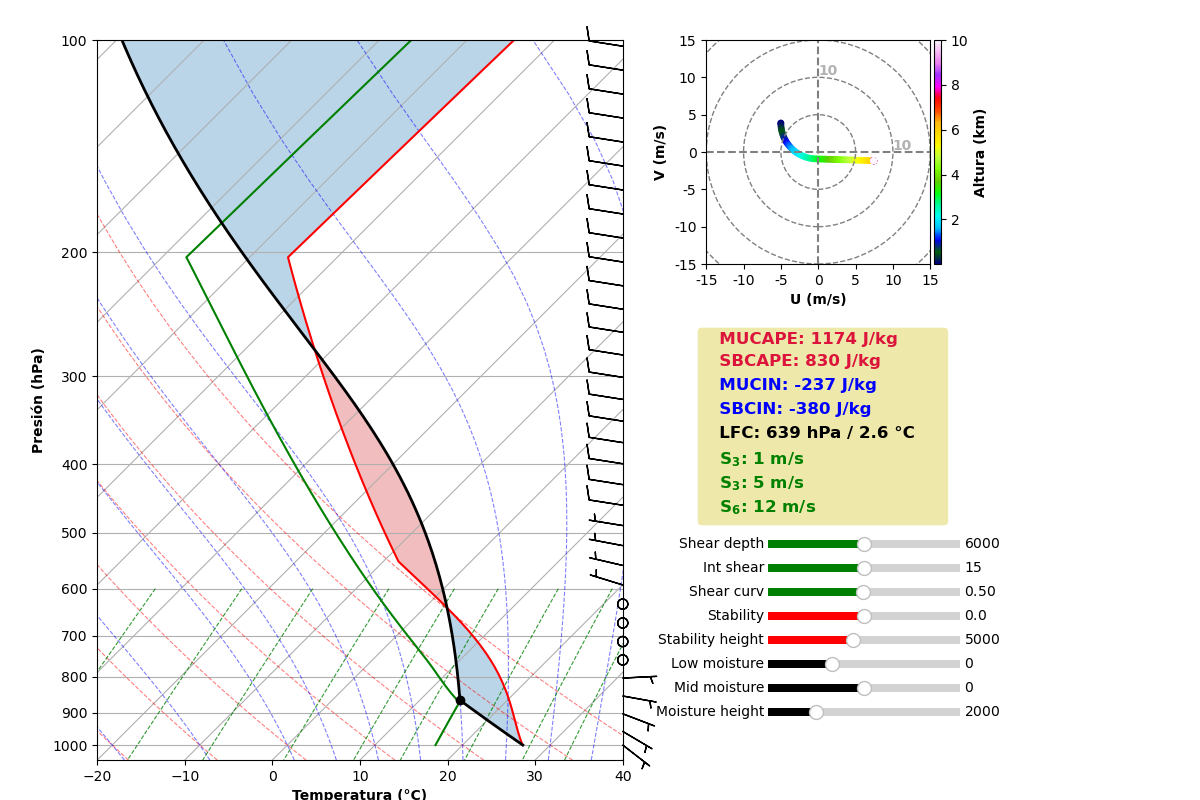

In [ ]:
#Siempre que se corre devuelta esta celda hay que correr la anterior, 
# para que aparezca la barra de colores

%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# Tu función para preparar el skewt + hodógrafa
fig, skew, h, ax_indices = prepare_skewt_hodograph()

# total_shear_depth  #Depth of circular shear. (tipical range [4000 , 8000]) 
# int_total_shear    #Total integrated shear (in m/s, tacking curvature into account) (tipical range [0 , 30])
# curved_shear_per   #Which proportion of the total shear depth will be curved. (tipical range [0 , 1])
# stability_factor   #Factor controling the stability change (tipical range [-1.5 , 1.5] )

input_sounding_path_orig = "/home/jorge.gacitua/datosmunin/em_quarter_ss/input_sounding" #sondeo base/original
input_sounding_path_mod = "/home/jorge.gacitua/datosmunin/em_quarter_ss/input_sounding_mod3" #sondeo modificado

modify_input_sounding(input_sounding_path_orig,input_sounding_path_mod, conf)
sounding = read_input_sounding(input_sounding_path_mod)

plot_sounding_clean(sounding)

# Creamos sliders en la figura
ax_sheardepth = fig.add_axes([0.64, 0.31, 0.16, 0.02])
ax_totalshear = fig.add_axes([0.64, 0.28, 0.16, 0.02])
ax_curvedper = fig.add_axes([0.64, 0.25, 0.16, 0.02])
ax_stability = fig.add_axes([0.64, 0.22, 0.16, 0.02])
ax_stability_height = fig.add_axes([0.64, 0.19, 0.16, 0.02])
ax_lowmoisture = fig.add_axes([0.64, 0.16, 0.16, 0.02])
ax_midmoisture = fig.add_axes([0.64, 0.13, 0.16, 0.02])
ax_midlow_moisture_height = fig.add_axes([0.64, 0.10, 0.16, 0.02])

slider_sheardepth = Slider(ax_sheardepth, 'Shear depth', 4000, 8000, valinit= 6000, valstep=1, initcolor='w')
slider_totalshear = Slider(ax_totalshear, 'Int shear', 0, 30, valinit=15, valstep=0.1, initcolor='w')
slider_curvedper = Slider(ax_curvedper, 'Shear curv', 0.01, 1, valinit=0.5, valstep=0.01, initcolor='w')
slider_stability = Slider(ax_stability, 'Stability', -1.5, 1.5, valinit=0, valstep=0.01, initcolor='w')
slider_stability_height = Slider(ax_stability_height, 'Stability height', 1000, 10000, valinit=5000, valstep=1, initcolor='w')
slider_lowmoisture = Slider(ax_lowmoisture, 'Low moisture', -15, 30, valinit=0, valstep=0.01, initcolor='w')
slider_midmoisture = Slider(ax_midmoisture, 'Mid moisture', -10, 10, valinit=0, valstep=0.01, initcolor='w')
slider_midlow_moisture_height = Slider(ax_midlow_moisture_height, 'Moisture height', 1000, 5000, valinit=2000, valstep=1, initcolor='w')

# Cambiar el color de la barra "progreso" (izquierda del handle)
slider_sheardepth.poly.set_facecolor('green')
slider_totalshear.poly.set_facecolor('green')
slider_curvedper.poly.set_facecolor('green')
slider_stability.poly.set_facecolor('red')
slider_stability_height.poly.set_facecolor('red')
slider_lowmoisture.poly.set_facecolor('black')
slider_midmoisture.poly.set_facecolor('black')
slider_midlow_moisture_height.poly.set_facecolor('black')

# Esta función modifica my_data y repinta el sounding
def update(val):

    #Parameters controling the shape of the wind profile.
    conf['modify_wind_profile'] = True  #Are we going to modify the original wind profile?
    conf['remove_mean_wind']    = True  #True for convection experiments, false for mountain wave experiments.
    conf['shear_type']          = 'Curved' #Posible choices: 'Linear','Curved'

    #For the Quarter shear case
    conf['total_shear_depth']  = slider_sheardepth.val   #Depth of circular shear. (tipical range [4000 , 8000]) 
    conf['int_total_shear']    = slider_totalshear.val      #Total integrated shear (in m/s, tacking curvature into account) (tipical range [0 , 30])
    conf['curved_shear_per']   = slider_curvedper.val       #Which proportion of the total shear depth will be curved. (tipical range [0 , 1])

    #Parameters controling the stability (temperature profile)
    conf['modify_stability'] = True          #Are we going to modify the original stability?
    conf['stability_factor'] = slider_stability.val         #Factor controling the stability change (tipical range [-1.5 , 1.5] )
    conf['stability_factor_height'] = slider_stability_height.val #2500+(param4*(10000-2500)) #Height of maximum warming / cooling. (tipical range [2500 , 10000 ] )

    #Parameters controling the shape of the moisture profile.
    conf['modify_moisture_profile'] = True       #Are we going to modify the original moisture profile?
    conf['dry_run']                 = False       #Assume 0.0 moisture content at all levels?
    conf['low_level_moisture_height'] = slider_midlow_moisture_height.val    #Low level moisture modification will take effect below this level.
    conf['low_level_moisture_mult_factor'] = slider_lowmoisture.val #Moisture modification for low levels (tipical range [-15.0 , 15.0] )   
    conf['mid_level_moisture_height'] = slider_midlow_moisture_height.val    #Mid level moisture modification will take effect above this level.
    conf['mid_level_moisture_mult_factor'] = slider_midmoisture.val  #Moisture modification factor for mid levels (tipical range [-10.0 , 10.0 ] )

    # Generar nuevo sounding
    modify_input_sounding(input_sounding_path_orig,input_sounding_path_mod, conf)

    new_sounding = read_input_sounding(input_sounding_path_mod)

    plot_sounding_clean(new_sounding)


# Vincular sliders a la función update
slider_sheardepth.on_changed(update)
slider_totalshear.on_changed(update)
slider_curvedper.on_changed(update)
slider_stability.on_changed(update)
slider_stability_height.on_changed(update)
slider_lowmoisture.on_changed(update)
slider_midmoisture.on_changed(update)
slider_midlow_moisture_height.on_changed(update)

plt.show()

/tmp/ipykernel_3749992/1796588274.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  h.ax.set_yticklabels([str(t) for t in ticks])
/tmp/ipykernel_3749992/1796588274.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  h.ax.set_xticklabels([str(t) for t in ticks])


True

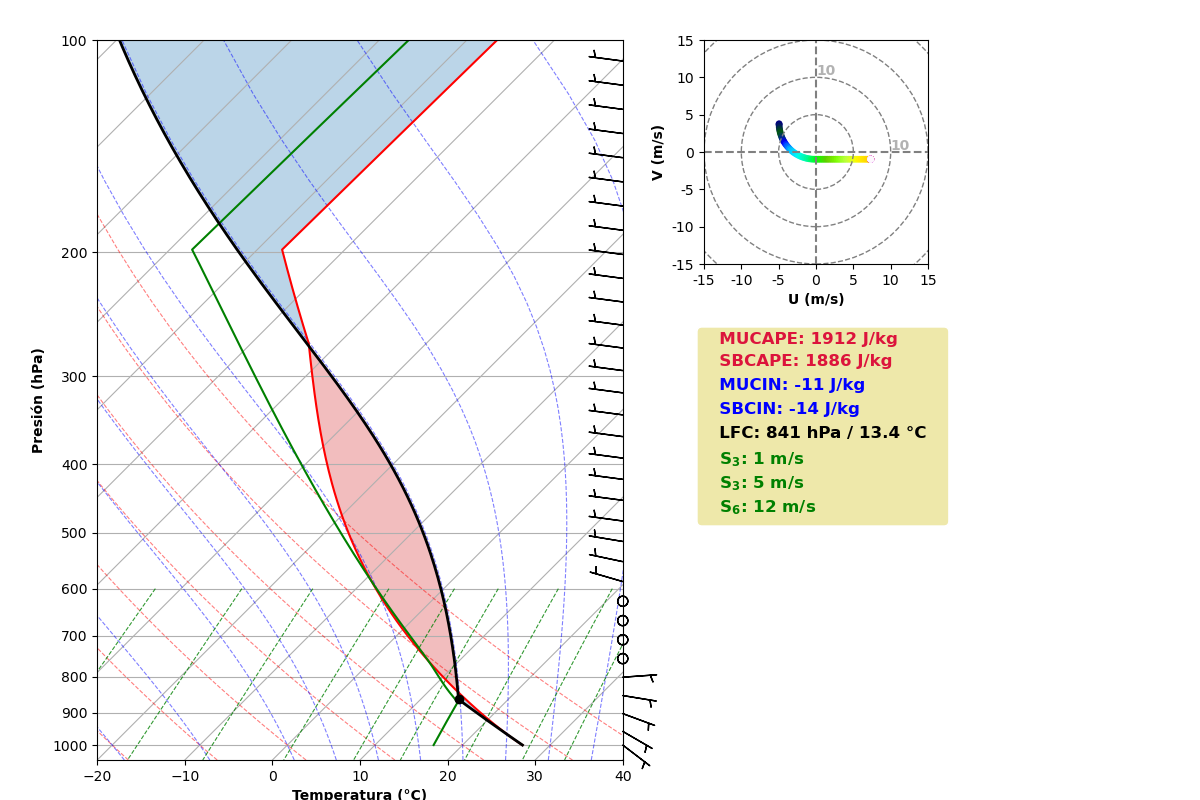

In [ ]:
import pickle

# num = 937

#with open(f"/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/TEST_Multi_4_vars_996/{num}/conf_{num}.pkl","rb") as archivo:
#    conf = pickle.load(archivo)

input_sounding_path_orig = "/home/jorge.gacitua/datosmunin/em_quarter_ss/input_sounding" #sondeo base/original
input_sounding_path_mod = "/home/jorge.gacitua/datosmunin/em_quarter_ss/input_sounding_mod3" #sondeo modificado

#Parameters controling the shape of the wind profile.
conf['modify_wind_profile'] = True  #Are we going to modify the original wind profile?
conf['remove_mean_wind']    = True  #True for convection experiments, false for mountain wave experiments.
conf['shear_type']          = 'Curved' #Posible choices: 'Linear','Curved'

#For the Quarter shear case
conf['total_shear_depth']  = 6000   #Depth of circular shear. (tipical range [4000 , 8000]) 
conf['int_total_shear']    = 15      #Total integrated shear (in m/s, tacking curvature into account) (tipical range [0 , 30])
conf['curved_shear_per']   = 0.5  #Which proportion of the total shear depth will be curved. (tipical range [0 , 1])

#Parameters controling the stability (temperature profile)
conf['modify_stability'] = True          #Are we going to modify the original stability?
conf['stability_factor'] = -1.5         #Factor controling the stability change (tipical range [-1.5 , 1.5] )
conf['stability_factor_height'] = 5000 #2500+(param4*(10000-2500)) #Height of maximum warming / cooling. (tipical range [2500 , 10000 ] )

#Parameters controling the shape of the moisture profile.
conf['modify_moisture_profile'] = True       #Are we going to modify the original moisture profile?
conf['dry_run']                 = False       #Assume 0.0 moisture content at all levels?
conf['low_level_moisture_height'] = 2000.0    #Low level moisture modification will take effect below this level.
conf['low_level_moisture_mult_factor'] = -15 #Moisture modification for low levels (tipical range [-15.0 , 15.0] )   
conf['mid_level_moisture_height'] = 2000.0    #Mid level moisture modification will take effect above this level.
conf['mid_level_moisture_mult_factor'] = -10  #Moisture modification factor for mid levels (tipical range [-10.0 , 10.0 ] )

fig, skew, h, ax_indices = prepare_skewt_hodograph()
modify_input_sounding(input_sounding_path_orig,input_sounding_path_mod, conf)
sounding = read_input_sounding(input_sounding_path_mod)

plot_sounding_clean(sounding)

td = mpcalc.dewpoint_from_specific_humidity(sounding['p']*units.hPa,sounding['qv']/1000 *units('kg/kg'))
np.min(sounding['t']*units.kelvin - td) <= 0